# Cloud ETL Pipeline — Notebook 2: S3 Data Analysis

**Author:** Mike Ichikawa  
**Date:** February 2026

Cross-date analysis over the 60-day backfilled S3 dataset.
Demonstrates querying Parquet data from S3 (or local) with pandas.

Run `python scripts/backfill.py --days 60` before executing this notebook.

In [1]:
import sys, os
sys.path.insert(0, '..')
os.environ.setdefault('LOCAL_MODE', 'true')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

import config
from src.load import S3Loader

plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

CITY_COLORS = {
    'Portland':      '#2C7BB6',
    'New York':      '#D7191C',
    'Los Angeles':   '#1A9641',
    'Chicago':       '#FF7F00',
    'Houston':       '#7B2D8B',
    'Phoenix':       '#E31A1C',
    'Philadelphia':  '#33A02C',
    'San Antonio':   '#FB9A99',
    'San Diego':     '#FDBF6F',
    'Dallas':        '#CAB2D6',
}

print(f'LOCAL_MODE: {config.LOCAL_MODE}')

LOCAL_MODE: True


In [2]:
# Load all processed data
loader = S3Loader()
dates = loader.list_processed_dates()

if not dates:
    print('No processed data found. Run: python scripts/backfill.py --days 60')
else:
    print(f'Found {len(dates)} processed dates: {dates[0]} → {dates[-1]}')

    frames = []
    for d in dates:
        df_d = loader.read_processed(d)
        if df_d is not None:
            frames.append(df_d)

    df = pd.concat(frames, ignore_index=True)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['date', 'city'])
    print(f'Total rows: {len(df):,} ({len(df["city"].unique())} cities × {len(dates)} days)')

Found 2 processed dates: 2026-01-15 → 2026-02-20
Total rows: 20 (10 cities × 2 days)


---
## 1. Temperature Trends Over Time

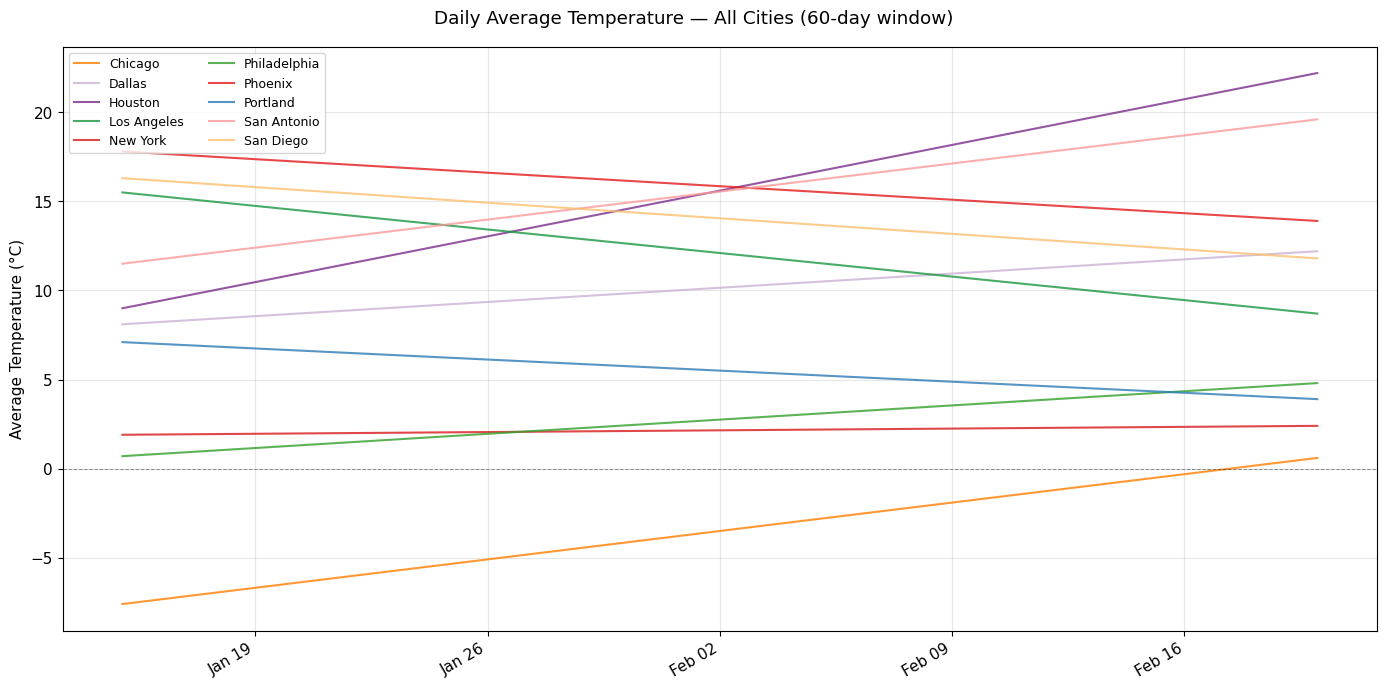

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Daily Average Temperature — All Cities (60-day window)')

for city, group in df.groupby('city'):
    ax.plot(group['date'], group['avg_temp_c'],
            color=CITY_COLORS.get(city, '#888888'),
            linewidth=1.5, alpha=0.8, label=city)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30, ha='right')
ax.set_ylabel('Average Temperature (°C)')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/outputs/nb2_temp_trends.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. City Temperature Distribution

In [4]:
city_stats = (
    df.groupby('city')
    .agg(
        mean_temp=('avg_temp_c', 'mean'),
        std_temp=('avg_temp_c', 'std'),
        max_temp=('max_temp_c', 'max'),
        min_temp=('min_temp_c', 'min'),
        total_precip=('precipitation_mm', 'sum'),
        heavy_rain_days=('is_heavy_rain', 'sum'),
        high_wind_days=('is_high_wind', 'sum'),
        extreme_temp_days=('is_extreme_temp', 'sum'),
    )
    .round(2)
    .sort_values('mean_temp', ascending=False)
)

print('City Statistics (60-day summary):')
print(city_stats.to_string())

City Statistics (60-day summary):
              mean_temp  std_temp  max_temp  min_temp  total_precip  heavy_rain_days  high_wind_days  extreme_temp_days
city                                                                                                                   
Phoenix           15.85      2.76      25.2       9.1           0.0                0               0                  0
Houston           15.60      9.33      25.2       3.8           2.1                0               0                  0
San Antonio       15.55      5.73      22.4       4.5           0.0                0               0                  0
San Diego         14.05      3.18      25.9       8.8           0.0                0               0                  0
Los Angeles       12.10      4.81      25.4       4.4           0.0                0               0                  0
Dallas            10.15      2.90      17.9       1.1           0.0                0               0                  0
Portla

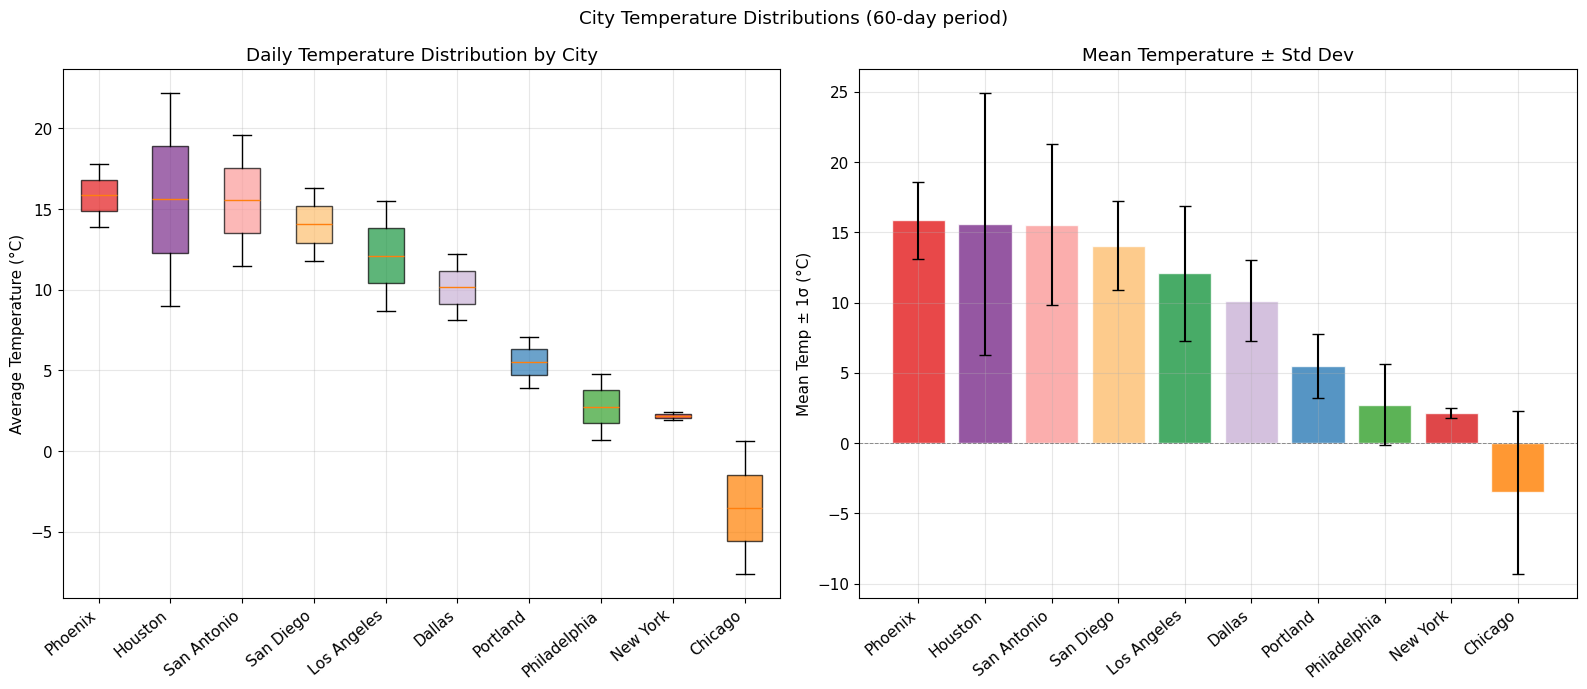

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('City Temperature Distributions (60-day period)')

# Box plot
city_order = city_stats.index.tolist()
colors = [CITY_COLORS.get(c, '#888') for c in city_order]

bp = axes[0].boxplot(
    [df[df['city']==c]['avg_temp_c'].values for c in city_order],
    labels=city_order, patch_artist=True, notch=False
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_xticklabels(city_order, rotation=40, ha='right')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].set_title('Daily Temperature Distribution by City')

# Mean ± 1 std bar chart
x = range(len(city_stats))
axes[1].bar(x, city_stats['mean_temp'], yerr=city_stats['std_temp'],
            color=colors, alpha=0.8, edgecolor='white', capsize=4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(city_stats.index, rotation=40, ha='right')
axes[1].set_ylabel('Mean Temp ± 1σ (°C)')
axes[1].set_title('Mean Temperature ± Std Dev')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/outputs/nb2_city_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Precipitation & Extreme Events

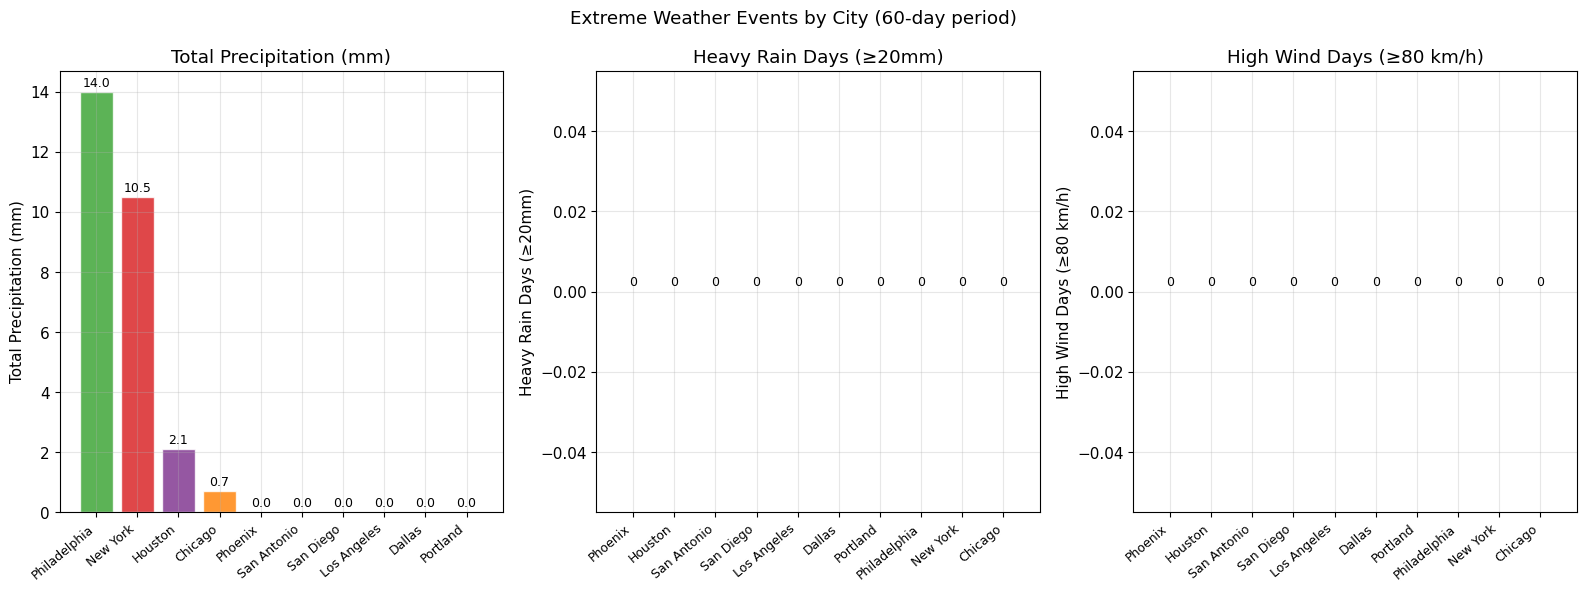

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Extreme Weather Events by City (60-day period)')

event_cols = [
    ('total_precip',       'Total Precipitation (mm)'),
    ('heavy_rain_days',    'Heavy Rain Days (≥20mm)'),
    ('high_wind_days',     'High Wind Days (≥80 km/h)'),
]

for ax, (col, label) in zip(axes, event_cols):
    data = city_stats[col].sort_values(ascending=False)
    bar_colors = [CITY_COLORS.get(c, '#888') for c in data.index]
    bars = ax.bar(range(len(data)), data.values, color=bar_colors, alpha=0.8, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f' if col == 'total_precip' else '%d', padding=2, fontsize=9)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.savefig('../data/outputs/nb2_extreme_events.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Pipeline Run Log Analysis

If DynamoDB / local run log exists, summarize pipeline performance.

Total pipeline runs logged: 2
Status counts: {'success': 2}
Avg duration: 6.47s
Total extreme events: 0


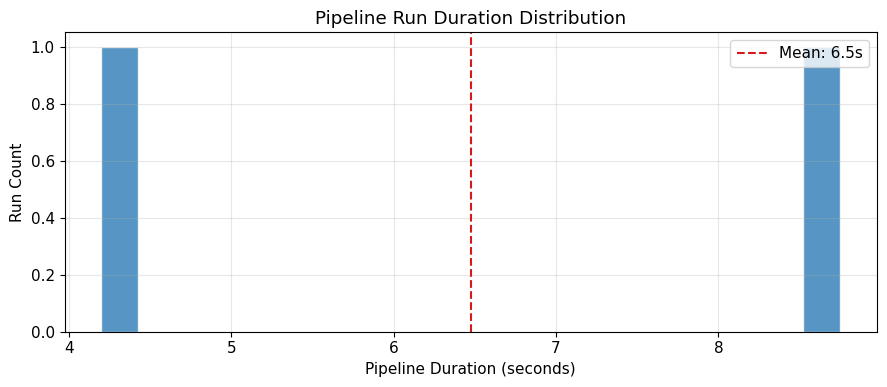

In [7]:
import json
log_path = config.OUTPUTS_DIR / 'run_log.jsonl'

if log_path.exists():
    runs = [json.loads(line) for line in log_path.read_text().strip().split('\n') if line]
    run_df = pd.DataFrame(runs)
    run_df['duration_seconds'] = pd.to_numeric(run_df['duration_seconds'], errors='coerce')

    print(f'Total pipeline runs logged: {len(run_df)}')
    print(f'Status counts: {run_df["status"].value_counts().to_dict()}')
    print(f'Avg duration: {run_df["duration_seconds"].mean():.2f}s')
    print(f'Total extreme events: {run_df["extreme_events"].astype(int).sum()}')

    # Duration histogram
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(run_df['duration_seconds'].dropna(), bins=20,
            color='#2C7BB6', edgecolor='white', alpha=0.8)
    ax.axvline(run_df['duration_seconds'].mean(), color='#D7191C',
               linestyle='--', label=f'Mean: {run_df["duration_seconds"].mean():.1f}s')
    ax.set_xlabel('Pipeline Duration (seconds)')
    ax.set_ylabel('Run Count')
    ax.set_title('Pipeline Run Duration Distribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/outputs/nb2_run_durations.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print(f'Run log not found at {log_path}. Run the backfill first.')

---
## 5. Key Findings

In [8]:
hottest_city = city_stats['mean_temp'].idxmax()
coldest_city = city_stats['mean_temp'].idxmin()
wettest_city = city_stats['total_precip'].idxmax()
windiest_city = city_stats['high_wind_days'].idxmax()

print('='*55)
print('KEY FINDINGS — 60-day Weather ETL Analysis')
print('='*55)
print(f'  Hottest city:    {hottest_city} ({city_stats.loc[hottest_city, "mean_temp"]:.1f}°C avg)')
print(f'  Coldest city:    {coldest_city} ({city_stats.loc[coldest_city, "mean_temp"]:.1f}°C avg)')
print(f'  Wettest city:    {wettest_city} ({city_stats.loc[wettest_city, "total_precip"]:.0f}mm total)')
print(f'  Windiest city:   {windiest_city} ({city_stats.loc[windiest_city, "high_wind_days"]:.0f} high-wind days)')
print(f'  Total records:   {len(df):,}')
print(f'  Total extreme events: {int(city_stats[["heavy_rain_days","high_wind_days","extreme_temp_days"]].sum().sum())}')
print('='*55)

KEY FINDINGS — 60-day Weather ETL Analysis
  Hottest city:    Phoenix (15.8°C avg)
  Coldest city:    Chicago (-3.5°C avg)
  Wettest city:    Philadelphia (14mm total)
  Windiest city:   Phoenix (0 high-wind days)
  Total records:   20
  Total extreme events: 0
